In [158]:
from qiskit_nature.second_q.hamiltonians import HeisenbergModel
from qiskit_nature.second_q.hamiltonians.lattices import line_lattice
from qiskit_nature.second_q.mappers import LogarithmicMapper
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info.analysis import Z2Symmetries
import numpy as np
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Lanczos_components import Liouvillian as BaseLiouvillian
from LiouvilleLanczos.Lanczos_components import Summation as Base_summation
from LiouvilleLanczos.Lanczos_components import Inner_product as Base_inner_product
from qiskit.primitives import BaseEstimatorV2
from qiskit_ibm_runtime.exceptions import RuntimeJobFailureError
from typing import Optional
from LiouvilleLanczos.Quantum_computer.QC_lanczos import separate_imag, dump_qpu_error


In [159]:
from LiouvilleLanczos.Quantum_computer.Hamiltonian import Line_Hubbard, BoundaryCondition
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()


In [160]:
def fermionic_op_to_matrix(op):
    qubit_op = mapper.map(op)
    return np.asarray(qubit_op.to_matrix(), dtype=complex)

def to_sparse_pauli(op):
    """
    Convert FermionicOp -> SparsePauliOp.
    Leave SparsePauliOp unchanged.
    """
    if isinstance(op, SparsePauliOp):
        return op

    if isinstance(op, FermionicOp):
        return mapper.map(op).simplify(atol=1e-12)

    raise TypeError(f"Unsupported operator type: {type(op)}")

In [161]:
import numpy as np
from itertools import combinations, product
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info.analysis import Z2Symmetries


# ------------------------------------------------------------
# Basic helpers
# ------------------------------------------------------------

def to_sparse_pauli_safe(op):
    """
    Convert Pauli/SparsePauliOp/operator-like object to SparsePauliOp when possible.
    If you already have your own to_sparse_pauli(Ham), you can use that before calling.
    """
    if isinstance(op, SparsePauliOp):
        return op

    if hasattr(op, "paulis"):
        # already SparsePauliOp-like
        return op

    if hasattr(op, "to_list"):
        return SparsePauliOp.from_list(op.to_list())

    raise TypeError(
        "Input must be a SparsePauliOp or something you convert to SparsePauliOp first."
    )


def op_to_mat(op):
    try:
        return np.asarray(op.to_matrix(sparse=False), dtype=complex)
    except TypeError:
        return np.asarray(op.to_matrix(), dtype=complex)


def pauli_label(op):
    """
    Works for qiskit.quantum_info.Pauli and SparsePauliOp.
    """
    if hasattr(op, "paulis"):
        return op.paulis[0].to_label()
    if hasattr(op, "to_label"):
        return op.to_label()
    raise TypeError(f"Cannot get Pauli label from object of type {type(op)}")


def as_sparse_pauli(op):
    """
    Convert Pauli or SparsePauliOp to SparsePauliOp.
    """
    if isinstance(op, SparsePauliOp):
        return op
    return SparsePauliOp(pauli_label(op), coeffs=[1.0])


def clean_array(x, tol=1e-10):
    x = np.array(x, copy=True)
    x[np.abs(x) < tol] = 0.0
    return x


def commutes(op_a, op_b, tol=1e-8):
    A = op_to_mat(op_a)
    B = op_to_mat(op_b)
    return np.linalg.norm(A @ B - B @ A) < tol


# ------------------------------------------------------------
# Choose clean single-qubit anticommuting Pauli
# ------------------------------------------------------------

def make_single_qubit_anticommuting_pauli(symmetry):
    """
    Given a Pauli symmetry S, choose a clean Hermitian single-qubit Pauli Q
    that anticommutes with S.

    Example:
        S = XYYXXY
        choose Q = ZIIIII or IXIIII etc., depending on first non-I.

    Qiskit Pauli labels are big-endian:
        leftmost character is qubit n-1,
        rightmost character is qubit 0.
    """
    label = pauli_label(symmetry)
    n = len(label)

    for string_index, char in enumerate(label):
        if char == "I":
            continue

        q_label = ["I"] * n

        if char == "X":
            q_label[string_index] = "Z"
        elif char == "Z":
            q_label[string_index] = "X"
        elif char == "Y":
            q_label[string_index] = "X"
        else:
            raise ValueError(f"Unexpected Pauli character: {char}")

        qubit_index = n - 1 - string_index
        Q = SparsePauliOp("".join(q_label), coeffs=[1.0])

        return Q, qubit_index

    raise ValueError("Identity symmetry cannot be tapered.")


# ------------------------------------------------------------
# Find mutually commuting subsets
# ------------------------------------------------------------

def is_mutually_commuting(symmetries, subset, tol=1e-8):
    for i, j in combinations(subset, 2):
        if not commutes(symmetries[i], symmetries[j], tol=tol):
            return False
    return True


def find_maximal_commuting_subsets(symmetries, tol=1e-8):
    """
    Return largest mutually commuting subsets of detected symmetries.
    If max size is 1, returns [(0,), (1,), ...].
    """
    n = len(symmetries)
    good = []

    for r in range(1, n + 1):
        for subset in combinations(range(n), r):
            if is_mutually_commuting(symmetries, subset, tol=tol):
                good.append(subset)

    if not good:
        return []

    max_size = max(len(s) for s in good)
    return [s for s in good if len(s) == max_size]


# ------------------------------------------------------------
# Sector projection verification
# ------------------------------------------------------------

def sector_projector(symmetries, sector_values):
    """
    P = product_i (I + s_i S_i)/2
    """
    S0 = op_to_mat(symmetries[0])
    dim = S0.shape[0]
    I = np.eye(dim, dtype=complex)

    P = I.copy()

    for S_op, s in zip(symmetries, sector_values):
        S = op_to_mat(S_op)
        P = P @ ((I + s * S) / 2)

    return (P + P.conj().T) / 2


def restrict_to_sector(H, symmetries, sector_values, tol=1e-8):
    Hmat = op_to_mat(H)
    P = sector_projector(symmetries, sector_values)

    evals, evecs = np.linalg.eigh(P)
    keep = evals > 1 - tol
    rank = int(np.sum(keep))

    if rank == 0:
        return None, rank

    B = evecs[:, keep]
    H_sector = B.conj().T @ Hmat @ B

    return H_sector, rank


def verify_tapered_against_sector(H, H_tapered, symmetries, sector_values, tol=1e-8):
    H_sector, rank = restrict_to_sector(H, symmetries, sector_values, tol=tol)

    if rank == 0:
        return {
            "sector_rank": 0,
            "spectra_match": False,
            "max_error": None,
            "e_sector": np.array([]),
            "e_tapered": np.sort(np.real_if_close(np.linalg.eigvalsh(op_to_mat(H_tapered)))),
        }

    e_sector = np.sort(np.real_if_close(np.linalg.eigvalsh(H_sector)))
    e_tapered = np.sort(np.real_if_close(np.linalg.eigvalsh(op_to_mat(H_tapered))))

    same_dim = len(e_sector) == len(e_tapered)
    spectra_match = same_dim and np.allclose(e_sector, e_tapered, atol=tol)
    max_error = np.max(np.abs(e_sector - e_tapered)) if same_dim else None

    return {
        "sector_rank": rank,
        "spectra_match": spectra_match,
        "max_error": max_error,
        "e_sector": e_sector,
        "e_tapered": e_tapered,
    }


# ------------------------------------------------------------
# Main wrapper
# ------------------------------------------------------------

def generate_tapered_hamiltonians(
    Ham,
    tol=1e-8,
    verify=True,
    verbose=True,
):
    """
    Input:
        Ham: SparsePauliOp Hamiltonian, or something already converted to SparsePauliOp.

    Output:
        A list of dictionaries. Each dictionary contains:
            - H_tapered
            - z2
            - subset
            - sector_values
            - sector_label
            - symmetries
            - sq_paulis
            - sq_list
            - verification info

    This wrapper:
        1. finds Z2 symmetries;
        2. finds maximal mutually commuting subsets;
        3. builds clean single-qubit anticommuting Paulis;
        4. generates all sector choices;
        5. tapers;
        6. optionally verifies spectra.
    """

    H = to_sparse_pauli_safe(Ham)

    z2_found = Z2Symmetries.find_z2_symmetries(H)

    if len(z2_found.symmetries) == 0:
        if verbose:
            print("No Z2 symmetries found.")
        return []

    if verbose:
        print("Detected Z2 symmetries:")
        for i, S in enumerate(z2_found.symmetries):
            print(f"{i}: {S}")

    subsets = find_maximal_commuting_subsets(z2_found.symmetries, tol=tol)

    if len(subsets) == 0:
        if verbose:
            print("No mutually commuting subsets found.")
        return []

    if verbose:
        print("\nMaximal mutually commuting subsets:")
        for subset in subsets:
            print(subset)

    results = []

    for subset in subsets:
        subset_symmetries = [as_sparse_pauli(z2_found.symmetries[i]) for i in subset]

        sq_paulis = []
        sq_list = []

        for S in subset_symmetries:
            Q, qidx = make_single_qubit_anticommuting_pauli(S)
            sq_paulis.append(Q)
            sq_list.append(qidx)

        for sector_values in product([1, -1], repeat=len(subset)):
            sector_values = list(sector_values)

            z2_sub = Z2Symmetries(
                symmetries=subset_symmetries,
                sq_paulis=sq_paulis,
                sq_list=sq_list,
                tapering_values=sector_values,
            )

            H_tapered = z2_sub.taper(H)

            sector_label = {
                f"S{symmetry_index}:{pauli_label(z2_found.symmetries[symmetry_index])}": value
                for symmetry_index, value in zip(subset, sector_values)
            }

            entry = {
                "H_tapered": H_tapered,
                "z2": z2_sub,
                "subset": subset,
                "sector_values": sector_values,
                "sector_label": sector_label,
                "symmetries": subset_symmetries,
                "sq_paulis": sq_paulis,
                "sq_list": sq_list,
            }

            if verify:
                verification = verify_tapered_against_sector(
                    H,
                    H_tapered,
                    subset_symmetries,
                    sector_values,
                    tol=tol,
                )

                entry.update(verification)

            results.append(entry)

            if verbose:
                print("\n" + "=" * 80)
                print("subset:", subset)
                print("sector:", sector_values)
                print("sector label:", sector_label)
                print("sq_list:", sq_list)
                print("original qubits:", H.num_qubits)
                print("tapered qubits:", H_tapered.num_qubits)

                if verify:
                    print("sector rank:", entry["sector_rank"])
                    print("spectra match:", entry["spectra_match"])
                    print("max error:", entry["max_error"])
                    print("lowest tapered energies:", clean_array(entry["e_tapered"][:6]))

    return results, z2_found

In [162]:
def relative_simplify_spo(ope:SparsePauliOp,eps:float):
    """
    relative simplify truncates terms with a relative participation smaller than eps.
    Qiskit quantum info sparse pauli operator based implementation.
    performs much better than slo.
    """

    return ope.simplify(atol=eps)

class Liouvillian_spo(BaseLiouvillian):
    """
    Sparse pauli operator based implementation of the Liouvillian.
    """
    def __init__(self,eps = 1e-10):
        """
        initialise with a relative precision. operator with smaller coefficients 
        are truncated.
        """
        self.eps = eps
    def __call__(self,H,A):
        """
        Compute the result of the Liouvillian for system with Hamiltonian H on 
        operator A.
        """
        comm = H@A-A@H
        return relative_simplify_spo(comm,self.eps)

class sum_spo(Base_summation):
    """
    Sum up to 3 sparse pauli operator
    """
    def __init__(self,eps=1e-10):
        """
        target relative precision of the results.
        """
        self.eps = eps
    def __call__(self,*X):
        """
        perform the sum
        """
        if len(X) > 2:
            A =  X[0]+X[1]+X[2]
        else:
            A = X[0]+X[1]
        return relative_simplify_spo(A,self.eps)

In [163]:
class tapered_inner_product_spo(Base_inner_product):
    """
    SparsePauliOp inner product with Z2 tapering.

    Computes:

        <psi_tapered| Taper( A B^dagger + B^dagger A ) |psi_tapered>

    where the tapering is done using the same Z2Symmetries object that was used
    to taper the Hamiltonian into the chosen sector.
    """

    def __init__(
        self,
        state: QuantumCircuit,
        estimator: BaseEstimatorV2,
        epsilon: float,
        taperer: Z2Symmetries,
        sector=None,
    ):
        """
        Parameters
        ----------
        state:
            QuantumCircuit preparing the state in the tapered Hilbert space.

        estimator:
            Qiskit EstimatorV2 object, e.g. StatevectorEstimator() or IBM Runtime EstimatorV2.

        epsilon:
            Coefficient truncation threshold.

        taperer:
            The sector-specific Z2Symmetries object, i.e. choice["z2"] from your
            generate_tapered_hamiltonians output.

        sector:
            Optional label, e.g. choice["sector_label"]. Only stored for bookkeeping.
            The actual tapering values are already inside taperer.
        """
        self.state = state
        self.estimator = estimator
        self.eps = epsilon
        self.taperer = taperer
        self.sector = sector

    def _taper_operator(self, op: SparsePauliOp) -> SparsePauliOp:
        """
        Taper a full-space SparsePauliOp using the stored Z2Symmetries object.

        If op is already on the tapered number of qubits, leave it alone.
        """
        op = relative_simplify_spo(op, self.eps)

        tapered_num_qubits = self.state.num_qubits

        if op.num_qubits == tapered_num_qubits:
            return op

        try:
            tapered = self.taperer.taper(op)
        except Exception as e:
            raise RuntimeError(
                "Failed to taper operator. Make sure you passed the sector-specific "
                "Z2Symmetries object choice['z2'], not the global z2_found object."
            ) from e

        # Qiskit may return a list if tapering_values were not fixed.
        if isinstance(tapered, list):
            if len(tapered) != 1:
                raise ValueError(
                    "Tapering returned multiple sector operators. This means your "
                    "Z2Symmetries object does not have fixed tapering_values. "
                    "Use choice['z2'] from generate_tapered_hamiltonians."
                )
            tapered = tapered[0]

        return relative_simplify_spo(tapered, self.eps)

    def _apply_layout_if_needed(self, obs: SparsePauliOp) -> SparsePauliOp:
        """
        Apply circuit layout only if the circuit has one.

        This makes the class work both for:
        - initialized statevector circuits, where layout is usually None;
        - transpiled IBM backend circuits, where layout exists.
        """
        layout = getattr(self.state, "layout", None)

        if layout is None:
            return obs

        try:
            return obs.apply_layout(layout)
        except Exception:
            return obs

    def _estimate_real_expectation(self, obs: SparsePauliOp) -> float:
        """
        Run estimator and return the real-valued expectation.
        """
        isa_obs = self._apply_layout_if_needed(obs)

        result = self.estimator.run([(self.state, isa_obs)]).result()
        evs = result[0].data.evs

        return float(np.real(np.asarray(evs).reshape(-1)[0]))

    def __call__(
        self,
        A: SparsePauliOp,
        B: SparsePauliOp,
        real_result: bool = False,
        Name: Optional[str] = None,
    ):
        """
        Compute the tapered inner product between A and B.

        Important:
        We build the full observable first:

            f = A B^dagger + B^dagger A

        and only then taper f.

        This is safer than tapering A and B separately, because A and B may
        individually change symmetry sector while the product preserves it.
        """
        Bc = B.adjoint()

        f = A @ Bc + Bc @ A
        f = relative_simplify_spo(f, self.eps)

        f_tapered = self._taper_operator(f)

        obs_real, obs_imag = separate_imag(f_tapered)

        out = complex(0)

        if len(obs_real) > 0 and any(np.abs(obs_real.coeffs) >= self.eps):
            try:
                out += self._estimate_real_expectation(obs_real)
            except RuntimeJobFailureError as e:
                isa_obs_real = self._apply_layout_if_needed(obs_real)
                dump_qpu_error((self.state, isa_obs_real), e, note="real")

        if not real_result and len(obs_imag) > 0 and any(np.abs(obs_imag.coeffs) >= self.eps):
            try:
                out_imag = self._estimate_real_expectation(obs_imag)
                out += out_imag * 1j
            except RuntimeJobFailureError as e:
                isa_obs_imag = self._apply_layout_if_needed(obs_imag)
                dump_qpu_error((self.state, isa_obs_imag), e, note="imag")

        return out

In [164]:
def ground_state_from_vector(psi):
    psi = np.asarray(psi, dtype=complex)
    psi = psi / np.linalg.norm(psi)

    n_qubits = int(np.log2(len(psi)))

    qc = QuantumCircuit(n_qubits)
    qc.initialize(psi, range(n_qubits))
    return qc

In [165]:
U = 4 
Ham = Line_Hubbard(
    -1,
    U/2,
    U,
    3,
    boundary_condition=BoundaryCondition.OPEN
)

H_sparse = to_sparse_pauli(Ham)

tapered_list, z2_found = generate_tapered_hamiltonians(
    H_sparse,
    verify=False,
    verbose=False,
)

choice = tapered_list[0]

H_tapered = choice["H_tapered"]
z2_sector = choice["z2"]
sector_label = choice["sector_label"]

E, S = np.linalg.eigh(H_tapered.to_matrix())

GS_vec = S[:, 0]
GS = ground_state_from_vector(GS_vec)

In [166]:
from qiskit.primitives import StatevectorEstimator

lanczos = Lanczos(
    inner_product=tapered_inner_product_spo(
        state=GS,
        estimator=StatevectorEstimator(),
        epsilon=1e-2,
        taperer=z2_sector,
        sector=sector_label,
    ),
    liouvillian=Liouvillian_spo(),
    sum=sum_spo(),
)

In [168]:
C0 = FermionicOp({"+_0": 1}, num_spin_orbitals=6)

lanczos_result = lanczos(
    H=H_sparse,
    f_0= to_sparse_pauli(C0),
    max_k=4
)

In [169]:
from LiouvilleLanczos.Green import CF_Green as CF

sample_green = CF(lanczos_result[0], lanczos_result[1])

/Users/asaad/Documents/Algolabs/Liouville-Lanczos/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/asaad/Documents/Algolabs/Liouville-Lanczos/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


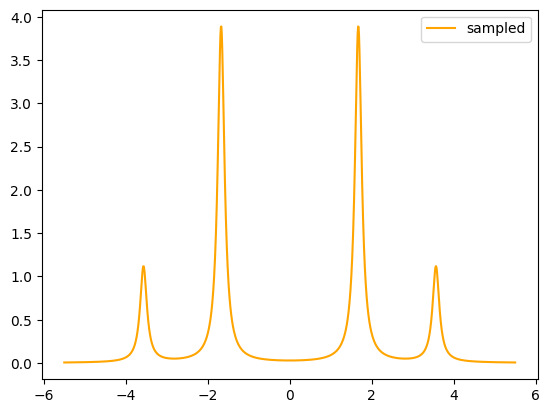

In [170]:
import matplotlib.pyplot as plt

w = np.linspace(-5.5,5.5,1000)-1e-1j
plt.plot(w,np.imag(sample_green(w)), label="sampled", color="orange")
plt.legend()
plt.show()
